In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
from langgraph.graph import StateGraph,MessagesState,START,END
from langgraph.checkpoint.memory import InMemorySaver

In [4]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model= 'gpt-4o-mini')

In [5]:
from langchain_core.messages import HumanMessage,trim_messages

In [9]:
def chatNode(state:MessagesState):
    messages = trim_messages(
        messages = state['messages'],
        max_tokens = 150,
        token_counter = llm,
        strategy='last'
    )
    print('current token count',llm.get_num_tokens_from_messages(messages))
    for message in messages:
        print(message.content)
    response = llm.invoke(messages)
    return {
        'messages':[response]
    }

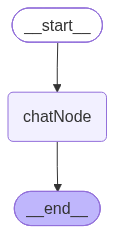

In [10]:
builder = StateGraph(state_schema=MessagesState)
builder.add_node('chatNode',chatNode)
builder.add_edge(START,'chatNode')
builder.add_edge('chatNode',END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)
graph

In [11]:
config = {"configurable": {"thread_id": "chat-1"}}

result = graph.invoke(
    {"messages": [{"role": "user", "content": "Hi, my name is Nitish."}]},
    config,
)

result["messages"][-1].content

current token count 15
Hi, my name is Nitish.


'Hi Nitish! How can I assist you today?'

In [12]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "I am learning LangGraph."}]},
    config,
)

result["messages"][-1].content

current token count 40
Hi, my name is Nitish.
Hi Nitish! How can I assist you today?
I am learning LangGraph.


"That's great to hear, Nitish! LangGraph is an interesting concept for working with language models and graph structures. What specific aspects of LangGraph are you focusing on, or do you have any questions or topics you'd like to explore?"

In [13]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "Can you explain short term memory?"}]},
    config,
)

result["messages"][-1].content

current token count 102
Hi, my name is Nitish.
Hi Nitish! How can I assist you today?
I am learning LangGraph.
That's great to hear, Nitish! LangGraph is an interesting concept for working with language models and graph structures. What specific aspects of LangGraph are you focusing on, or do you have any questions or topics you'd like to explore?
Can you explain short term memory?


'Short-term memory (STM) refers to the capacity for holding a small amount of information in an active, readily accessible state for a brief period. Here are some key points to understand about short-term memory:\n\n1. **Duration**: Short-term memory typically lasts for about 15 to 30 seconds unless the information is actively maintained, such as through rehearsal (e.g., repeating a phone number).\n\n2. **Capacity**: The classic theory proposed by psychologist George A. Miller suggests that the capacity of short-term memory is about 7 ± 2 items (often referred to as "Miller\'s Law"). This means that, on average, a person can hold around 5 to 9 pieces of information in short-term memory at once.\n\n3. **Encoding**: Information in short-term memory is often encoded acoustically (by sound), but it can also be visual or semantic depending on the nature of the information.\n\n4. **Function**: Short-term memory is crucial for everyday tasks and processes such as problem-solving, language com

In [14]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "What is my name?"}]},
    config,
)

result["messages"][-1].content

current token count 12
What is my name?


"I don't have access to personal data about users unless it has been shared in the conversation. So, I don't know your name. How can I assist you today?"

In [15]:
for item in graph.get_state({"configurable": {"thread_id": "chat-1"}}).values['messages']:
    print(item.content)
    print('-'*120)

Hi, my name is Nitish.
------------------------------------------------------------------------------------------------------------------------
Hi Nitish! How can I assist you today?
------------------------------------------------------------------------------------------------------------------------
I am learning LangGraph.
------------------------------------------------------------------------------------------------------------------------
That's great to hear, Nitish! LangGraph is an interesting concept for working with language models and graph structures. What specific aspects of LangGraph are you focusing on, or do you have any questions or topics you'd like to explore?
------------------------------------------------------------------------------------------------------------------------
Can you explain short term memory?
------------------------------------------------------------------------------------------------------------------------
Short-term memory (STM) refers to 